In [1]:
import sys
import os

# Agrega el directorio anterior al sys.path
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import my_module as mm
from scipy import stats
import importlib
import scipy.linalg as la
from getdist import MCSamples, plots
from scipy.constants import c

#Refresh the changes made on my_module files
importlib.reload(mm)


#Matplotlib parameters

plt.rcParams.update({
    # Font
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # Or your preferred from the list
    "font.size": 14,                 # Base font size for all text

    # Axes labels & title sizes
    "axes.titlesize": 16,
    "axes.labelsize": 14,

    # Tick parameters
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

})

plt.rcParams['text.usetex'] = True

In [2]:
#Pantheon+ data import
data_Pan, cov_Pan = mm.data_import.Pantheon_data(cut=False)

#DES data import
data_DES, cov_DES = mm.data_import.DES_data(cut=False)

#Sort data by redshift
data_DES = data_DES.sort_values(by='zHD')
data_Pan = data_Pan.sort_values(by='zHD')


In [12]:
text_folder = '../../text/images/'

In [13]:
#Define parameter names and labels
param_names = ['om_m', 'H0']  
labels = [r'\Omega_m', r'H_0']

#data import from MCMC chains
data_Pan_cluster = np.loadtxt("samples_Pan_cluster.txt")
data_DES_cluster = np.loadtxt("samples_DES_cluster.txt")
data_DES5yr = np.loadtxt("../cap5_cap6_fulldatasets/samples_DES.txt")
data_Pantheon = np.loadtxt("../cap5_cap6_fulldatasets/samples_Pan.txt")


#Convert it into MCSamples object
samples_Pan_cluster = MCSamples(samples=data_Pan_cluster, names=param_names, labels=labels)
samples_DES_cluster = MCSamples(samples=data_DES_cluster, names=param_names, labels=labels)
samples_DES = MCSamples(samples=data_DES5yr, names=param_names, labels=labels)
samples_Pantheon = MCSamples(samples=data_Pantheon, names=param_names, labels=labels)

# Function to summarize MCSamples
def summarize_mc_samples(mc_sample, sample_name):
    """
    Print mean ± standard deviation for each parameter in an MCSamples object.
    
    Parameters
    ----------
    mc_sample : MCSamples
        MCSamples object containing the MCMC samples.
    """
    param_names = mc_sample.getParamNames().names
    for name in param_names:
        mean = mc_sample.mean(name)
        err = mc_sample.std(name)
        print(f"{sample_name} - {name}: {mean:.4f} ± {err:.4f}")

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


Pantheon+ - om_m	\Omega_m: 0.3668 ± 0.0416
Pantheon+ - H0	H_0: 72.6310 ± 0.5617
Pantheon+ \, with \, clustering - om_m	\Omega_m: 0.3954 ± 0.0434
Pantheon+ \, with \, clustering - H0	H_0: 72.1234 ± 0.5677


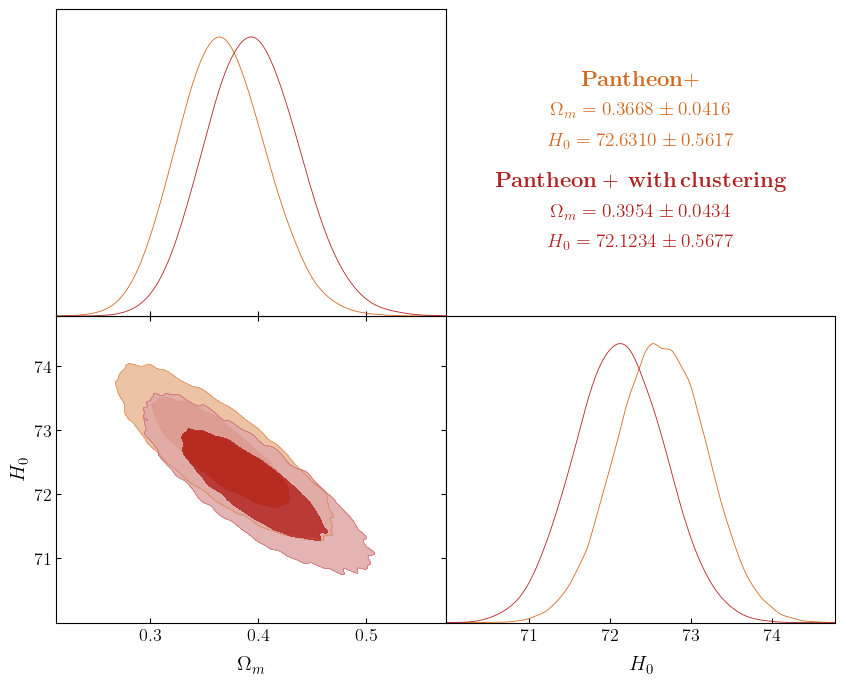

In [14]:
mm.make_triangle_plot(
    [samples_Pantheon, samples_Pan_cluster],
    labels=labels,
    colors=('chocolate', 'firebrick'),
    outfile=text_folder + 'Pan_clustering.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['Pantheon+', 'Pantheon+ \, with \, clustering']
)

summarize_mc_samples(samples_Pantheon, sample_name='Pantheon+')
summarize_mc_samples(samples_Pan_cluster, sample_name='Pantheon+ \, with \, clustering')

DES 5yr - om_m	\Omega_m: 0.2762 ± 0.0222
DES 5yr - H0	H_0: 69.5402 ± 0.5423
DES 5yr \, with \, clustering - om_m	\Omega_m: 0.2761 ± 0.0223
DES 5yr \, with \, clustering - H0	H_0: 69.5277 ± 0.5460


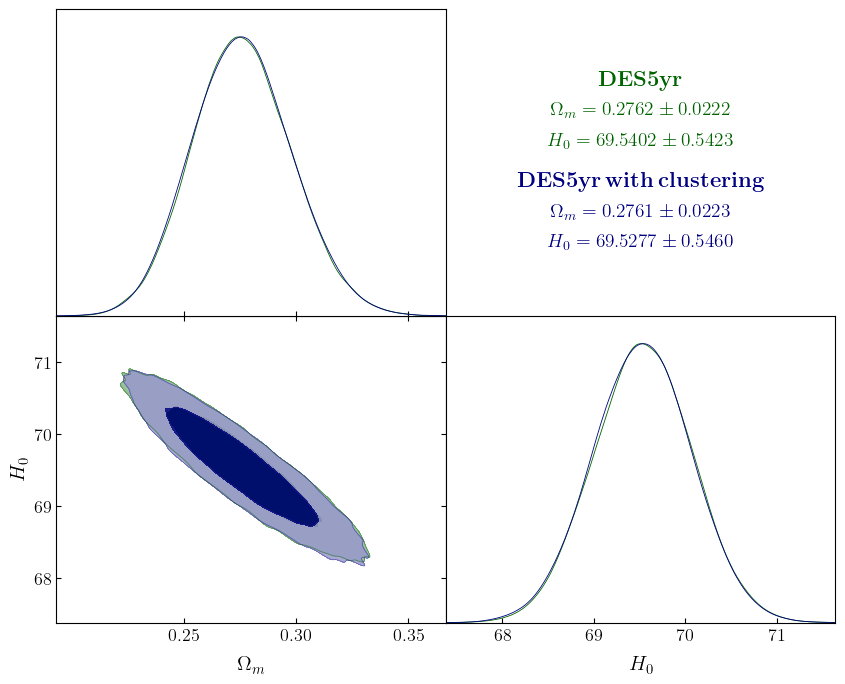

In [15]:
mm.make_triangle_plot(
    [samples_DES, samples_DES_cluster],
    labels=labels,
    colors=('darkgreen', 'navy'),
    outfile=text_folder + 'DES_clustering.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['DES 5yr', 'DES 5yr \, with \, clustering']
)

summarize_mc_samples(samples_DES, sample_name='DES 5yr')
summarize_mc_samples(samples_DES_cluster, sample_name='DES 5yr \, with \, clustering')